<a href="https://colab.research.google.com/github/sariyya-aliyeva/Intrusion_Detection_Systems/blob/main/3_Stage2_CNN_BiLSTM_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# STAGE 2: PREPARE ATTACK-ONLY DATA
# =========================

attack_train_mask = y_train != benign_class
attack_val_mask = y_val != benign_class
attack_test_mask = y_test != benign_class

X_train_attack = X_train_scaled[attack_train_mask]
X_val_attack = X_val_scaled[attack_val_mask]
X_test_attack = X_test_scaled[attack_test_mask]

y_train_attack_original = y_train[attack_train_mask]
y_val_attack_original = y_val[attack_val_mask]
y_test_attack_original = y_test[attack_test_mask]

print("Attack train shape:", X_train_attack.shape)
print("Attack validation shape:", X_val_attack.shape)
print("Attack test shape:", X_test_attack.shape)

print("\nOriginal attack labels:")
print(np.unique(y_train_attack_original))

Attack train shape: (92521, 78)
Attack validation shape: (19826, 78)
Attack test shape: (19826, 78)

Original attack labels:
[1 2 3 4 5]


In [ ]:
# =========================
# RELABEL ATTACK CLASSES
# =========================

attack_classes = [cls for cls in range(len(label_encoder.classes_)) if cls != benign_class]

attack_label_mapping = {
    old_label: new_label
    for new_label, old_label in enumerate(attack_classes)
}

reverse_attack_label_mapping = {
    new_label: old_label
    for old_label, new_label in attack_label_mapping.items()
}

y_train_attack = np.array([attack_label_mapping[label] for label in y_train_attack_original])
y_val_attack = np.array([attack_label_mapping[label] for label in y_val_attack_original])
y_test_attack = np.array([attack_label_mapping[label] for label in y_test_attack_original])

attack_class_names = [label_encoder.classes_[old_label] for old_label in attack_classes]

print("Attack label mapping:")
for new_label, old_label in reverse_attack_label_mapping.items():
    print(f"{new_label} -> {label_encoder.classes_[old_label]}")


Attack label mapping:
0 -> Bot
1 -> DDoS
2 -> Web Attack - Brute Force
3 -> Web Attack - SQL Injection
4 -> Web Attack - XSS


In [ ]:
# =========================
# RESHAPE DATA
# =========================

X_train_attack_dl = np.expand_dims(X_train_attack, axis=1)
X_val_attack_dl = np.expand_dims(X_val_attack, axis=1)
X_test_attack_dl = np.expand_dims(X_test_attack, axis=1)

print("Attack DL Train shape:", X_train_attack_dl.shape)
print("Attack DL Validation shape:", X_val_attack_dl.shape)
print("Attack DL Test shape:", X_test_attack_dl.shape)

Attack DL Train shape: (92521, 1, 78)
Attack DL Validation shape: (19826, 1, 78)
Attack DL Test shape: (19826, 1, 78)


In [ ]:
# =========================
# DATALOADER PREPARATION TensorDataset + DataLoader
# =========================

X_train_attack_tensor = torch.tensor(X_train_attack_dl, dtype=torch.float32)
X_val_attack_tensor = torch.tensor(X_val_attack_dl, dtype=torch.float32)
X_test_attack_tensor = torch.tensor(X_test_attack_dl, dtype=torch.float32)

y_train_attack_tensor = torch.tensor(y_train_attack, dtype=torch.long)
y_val_attack_tensor = torch.tensor(y_val_attack, dtype=torch.long)
y_test_attack_tensor = torch.tensor(y_test_attack, dtype=torch.long)

train_attack_dataset = TensorDataset(X_train_attack_tensor, y_train_attack_tensor)
val_attack_dataset = TensorDataset(X_val_attack_tensor, y_val_attack_tensor)
test_attack_dataset = TensorDataset(X_test_attack_tensor, y_test_attack_tensor)

batch_size_stage2 = 512

train_attack_loader = DataLoader(train_attack_dataset, batch_size=batch_size_stage2, shuffle=True)
val_attack_loader = DataLoader(val_attack_dataset, batch_size=batch_size_stage2, shuffle=False)
test_attack_loader = DataLoader(test_attack_dataset, batch_size=batch_size_stage2, shuffle=False)

print("Attack train batches:", len(train_attack_loader))
print("Attack validation batches:", len(val_attack_loader))
print("Attack test batches:", len(test_attack_loader))

Attack train batches: 181
Attack validation batches: 39
Attack test batches: 39


In [ ]:
# =========================
# STAGE 2: CLASS WEIGHTS FOR ATTACK CLASSES
# =========================

attack_classes_new = np.unique(y_train_attack)

attack_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=attack_classes_new,
    y=y_train_attack
)

attack_class_weights_tensor = torch.tensor(
    attack_class_weights,
    dtype=torch.float32
).to(device)

print("Attack class weights:")
for i, w in enumerate(attack_class_weights):
    print(f"{i} ({attack_class_names[i]}): {w:.4f}")

Attack class weights:
0 (Bot): 13.4478
1 (DDoS): 0.2065
2 (Web Attack - Brute Force): 17.5395
3 (Web Attack - SQL Injection): 1233.6133
4 (Web Attack - XSS): 40.5794


In [ ]:
# =========================
# CNN + BiLSTM + ATTENTION ATTACK CLASSIFIER
# =========================

class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_output):
        scores = self.attention(lstm_output)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(weights * lstm_output, dim=1)
        return context, weights


class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=input_dim,
            out_channels=64,
            kernel_size=1
        )

        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.attention = AttentionLayer(hidden_dim=64)

        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)

        context, attn_weights = self.attention(lstm_out)

        x = self.fc1(context)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x, attn_weights


input_dim_stage2 = X_train_attack_dl.shape[2]
num_attack_classes = len(attack_class_names)

model_stage2 = CNN_BiLSTM_Attention(
    input_dim=input_dim_stage2,
    num_classes=num_attack_classes
).to(device)

criterion_stage2 = nn.CrossEntropyLoss(weight=attack_class_weights_tensor)
optimizer_stage2 = optim.Adam(model_stage2.parameters(), lr=0.001)

print(model_stage2)

CNN_BiLSTM_Attention(
  (conv1): Conv1d(78, 64, kernel_size=(1,), stride=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (attention): AttentionLayer(
    (attention): Linear(in_features=128, out_features=1, bias=True)
  )
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=5, bias=True)
)


In [ ]:
# =========================
# MODEL TRAINING
# =========================

epochs_stage2 = 10

stage2_train_losses = []
stage2_val_losses = []
stage2_train_accuracies = []
stage2_val_accuracies = []

for epoch in range(epochs_stage2):
    model_stage2.train()

    running_loss = 0.0
    all_train_preds = []
    all_train_labels = []

    for X_batch, y_batch in train_attack_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_stage2.zero_grad()

        outputs, _ = model_stage2(X_batch)
        loss = criterion_stage2(outputs, y_batch)

        loss.backward()
        optimizer_stage2.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(y_batch.cpu().numpy())

    train_loss = running_loss / len(train_attack_loader)
    train_acc = accuracy_score(all_train_labels, all_train_preds)

    model_stage2.eval()

    running_val_loss = 0.0
    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_attack_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs, _ = model_stage2(X_batch)
            loss = criterion_stage2(outputs, y_batch)

            running_val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_val_preds.extend(preds.cpu().numpy())
            all_val_labels.extend(y_batch.cpu().numpy())

    val_loss = running_val_loss / len(val_attack_loader)
    val_acc = accuracy_score(all_val_labels, all_val_preds)

    stage2_train_losses.append(train_loss)
    stage2_val_losses.append(val_loss)
    stage2_train_accuracies.append(train_acc)
    stage2_val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs_stage2} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/10 | Train Loss: 0.7330 | Train Acc: 0.9168 | Val Loss: 0.4452 | Val Acc: 0.9933
Epoch 2/10 | Train Loss: 0.4194 | Train Acc: 0.9895 | Val Loss: 0.3867 | Val Acc: 0.9883
Epoch 3/10 | Train Loss: 0.4045 | Train Acc: 0.9892 | Val Loss: 0.3796 | Val Acc: 0.9933
Epoch 4/10 | Train Loss: 0.3928 | Train Acc: 0.9895 | Val Loss: 0.3841 | Val Acc: 0.9933
Epoch 5/10 | Train Loss: 0.3896 | Train Acc: 0.9897 | Val Loss: 0.3712 | Val Acc: 0.9887
Epoch 6/10 | Train Loss: 0.3949 | Train Acc: 0.9893 | Val Loss: 0.3770 | Val Acc: 0.9885
Epoch 7/10 | Train Loss: 0.3843 | Train Acc: 0.9893 | Val Loss: 0.3713 | Val Acc: 0.9934
Epoch 8/10 | Train Loss: 0.3783 | Train Acc: 0.9898 | Val Loss: 0.3746 | Val Acc: 0.9940
Epoch 9/10 | Train Loss: 0.3789 | Train Acc: 0.9897 | Val Loss: 0.3721 | Val Acc: 0.9880
Epoch 10/10 | Train Loss: 0.3769 | Train Acc: 0.9897 | Val Loss: 0.3620 | Val Acc: 0.9887


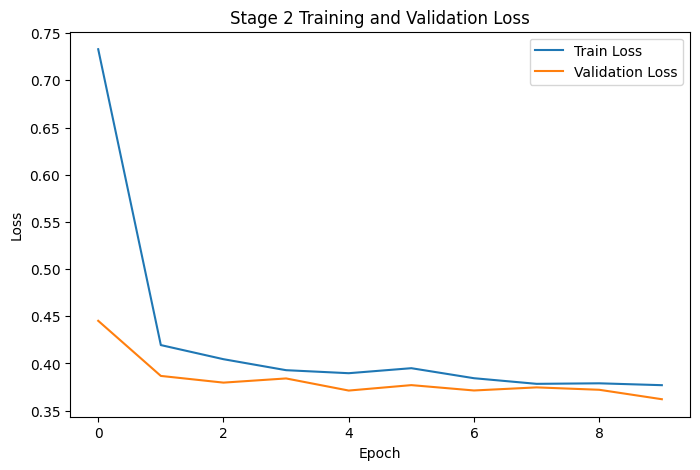

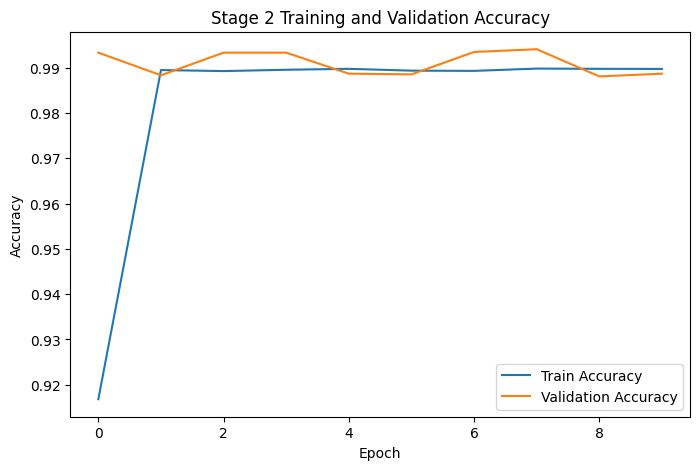

In [ ]:
# =========================
# STAGE 2: TRAINING CURVES
# =========================

plt.figure(figsize=(8,5))
plt.plot(stage2_train_losses, label="Train Loss")
plt.plot(stage2_val_losses, label="Validation Loss")
plt.title("Stage 2 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(stage2_train_accuracies, label="Train Accuracy")
plt.plot(stage2_val_accuracies, label="Validation Accuracy")
plt.title("Stage 2 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Stage 2 Test Accuracy: 0.9889034601028952

Stage 2 Classification Report:
                            precision    recall  f1-score   support

                       Bot       0.98      1.00      0.99       295
                      DDoS       1.00      1.00      1.00     19204
  Web Attack - Brute Force       1.00      0.06      0.12       226
Web Attack - SQL Injection       0.08      1.00      0.15         3
          Web Attack - XSS       0.35      0.98      0.51        98

                  accuracy                           0.99     19826
                 macro avg       0.68      0.81      0.55     19826
              weighted avg       1.00      0.99      0.99     19826


Stage 2 Confusion Matrix:
[[  295     0     0     0     0]
 [    6 19198     0     0     0]
 [    0     0    14    32   180]
 [    0     0     0     3     0]
 [    0     0     0     2    96]]


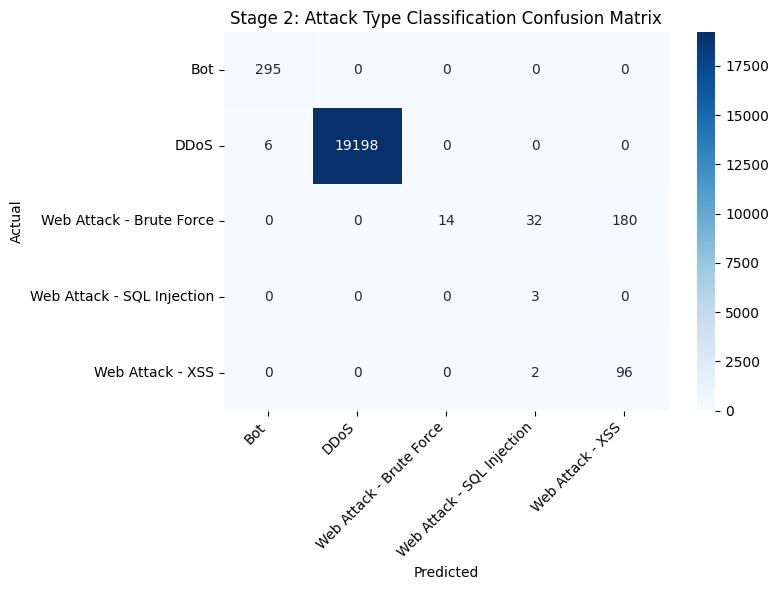

In [ ]:
# =========================
# ATTACK TYPE CLASSIFICATION EVALUATION
# =========================

model_stage2.eval()

stage2_test_preds = []
stage2_test_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_attack_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs, _ = model_stage2(X_batch)
        preds = torch.argmax(outputs, dim=1)

        stage2_test_preds.extend(preds.cpu().numpy())
        stage2_test_labels.extend(y_batch.cpu().numpy())

stage2_test_acc = accuracy_score(stage2_test_labels, stage2_test_preds)

print("Stage 2 Test Accuracy:", stage2_test_acc)

print("\nStage 2 Classification Report:")
print(
    classification_report(
        stage2_test_labels,
        stage2_test_preds,
        target_names=attack_class_names,
        zero_division=0
    )
)

cm_stage2 = confusion_matrix(stage2_test_labels, stage2_test_preds)

print("\nStage 2 Confusion Matrix:")
print(cm_stage2)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_stage2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=attack_class_names,
    yticklabels=attack_class_names
)

plt.title("Stage 2: Attack Type Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

End-to-End Two-Stage IDS Evaluation
Accuracy: 0.8695158506676356
                            precision    recall  f1-score   support

                    BENIGN       0.93      0.90      0.91     68246
                       Bot       0.00      0.05      0.01       295
                      DDoS       0.89      0.78      0.83     19204
  Web Attack - Brute Force       0.04      0.06      0.05       226
Web Attack - SQL Injection       0.00      0.00      0.00         3
          Web Attack - XSS       0.00      0.01      0.01        98

                  accuracy                           0.87     88072
                 macro avg       0.31      0.30      0.30     88072
              weighted avg       0.91      0.87      0.89     88072



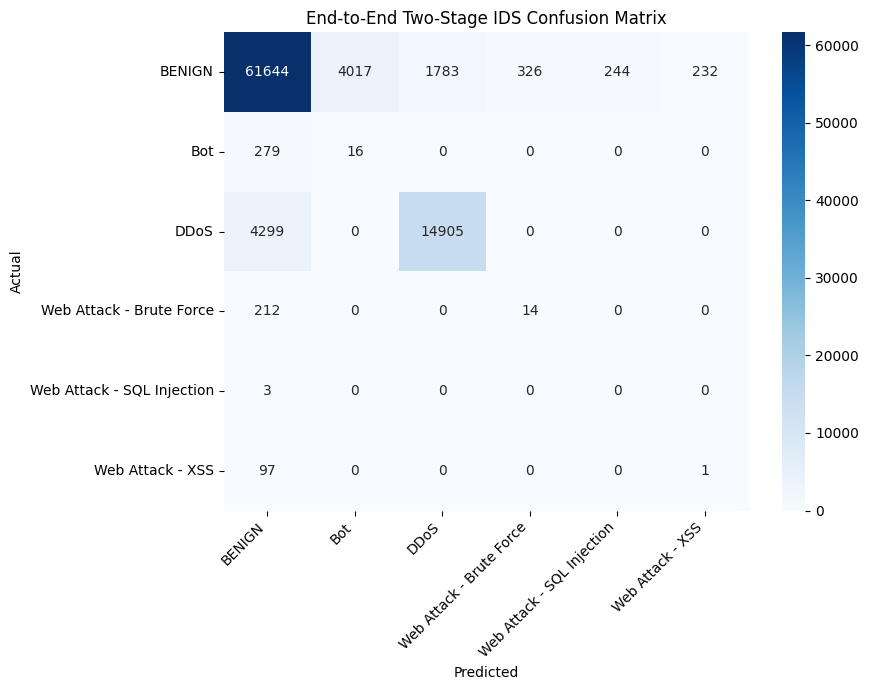

In [ ]:
# END-TO-END TWO-STAGE IDS EVALUATION

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

autoencoder.eval()

with torch.no_grad():
    recon_test = autoencoder(X_test_tensor)
    errors_test = torch.mean(
        (X_test_tensor - recon_test) ** 2,
        dim=1
    ).cpu().numpy()

stage1_test_pred_binary = (errors_test > threshold_stage1).astype(int)

final_predictions = np.full_like(y_test, fill_value=benign_class)

attack_indices = np.where(stage1_test_pred_binary == 1)[0]

X_stage2_input = X_test_scaled[attack_indices]
X_stage2_input_dl = np.expand_dims(X_stage2_input, axis=1)
X_stage2_input_tensor = torch.tensor(X_stage2_input_dl, dtype=torch.float32).to(device)

model_stage2.eval()

with torch.no_grad():
    outputs, _ = model_stage2(X_stage2_input_tensor)
    stage2_preds = torch.argmax(outputs, dim=1).cpu().numpy()

stage2_original_preds = np.array([
    reverse_attack_label_mapping[pred]
    for pred in stage2_preds
])

final_predictions[attack_indices] = stage2_original_preds

print("End-to-End Two-Stage IDS Evaluation")
print("Accuracy:", accuracy_score(y_test, final_predictions))

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

cm_end_to_end = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(9,7))
sns.heatmap(
    cm_end_to_end,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("End-to-End Two-Stage IDS Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()